# Lab 2: Seq2Seq Neural Machine Translation

## 📚 Objective
Implement a basic **Sequence-to-Sequence (Seq2Seq)** model for neural machine translation using GRU-based encoder-decoder architecture.

## 🎯 Learning Goals
By completing this lab, you will:
1. ✅ Understand the **encoder-decoder** architecture
2. ✅ Implement **GRU-based Encoder** and **Decoder**
3. ✅ Train with **teacher forcing**
4. ✅ Perform **greedy decoding** at inference
5. ✅ Evaluate translation quality

## 🏗️ Architecture Overview

```
Source: "i am a student"
   ↓
[Encoder: GRU]
   ↓
Hidden State (context vector)
   ↓
[Decoder: GRU] → "tôi" → "là" → "sinh" → "viên" → <EOS>
```

**Key concept:** The entire source sentence is compressed into a fixed-size hidden state, which the decoder uses to generate the target sequence word by word.

---

## 📋 Tasks
1. **Data Preparation**: Load and encode parallel corpus with `<BOS>`, `<EOS>`, `<PAD>` tokens
2. **Encoder**: Implement GRU encoder to process source sentence
3. **Decoder**: Implement GRU decoder to generate target sentence
4. **Training**: Train with teacher forcing and cross-entropy loss
5. **Inference**: Greedy decoding to generate translations
6. **Evaluation**: Measure accuracy on dev set

---

Let's begin! 🚀

In [1]:
import random
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)


Using device: cpu


## 1. Load parallel data

In [2]:
def load_lines(path):
    with open(path, "r", encoding="utf-8") as f:
        return [line.strip() for line in f if line.strip()]

train_src = load_lines("data/train.en")
train_tgt = load_lines("data/train.vi")
dev_src = load_lines("data/dev.en")
dev_tgt = load_lines("data/dev.vi")

print(train_src[:3])
print(train_tgt[:3])


['i am a student', 'i am a teacher', 'he likes football']
['tôi là sinh viên', 'tôi là giáo viên', 'anh ấy thích bóng đá']


## 2. Build vocabularies
Reuse or complete the utilities from Lab 1.

In [3]:
SPECIAL_TOKENS = ["<PAD>", "<BOS>", "<EOS>", "<UNK>"]

class Vocab:
    """Vocabulary class với special tokens cho Seq2Seq"""
    def __init__(self):
        self.word2id = {}
        self.id2word = {}
        # Thêm special tokens với ID cố định
        for token in SPECIAL_TOKENS:
            self.add_word(token)

    def add_word(self, word):
        if word not in self.word2id:
            idx = len(self.word2id)
            self.word2id[word] = idx
            self.id2word[idx] = word

    def build(self, sentences):
        """Xây dựng vocabulary từ danh sách câu"""
        for sentence in sentences:
            words = tokenize(sentence)
            for word in words:
                self.add_word(word)

    def encode(self, sentence):
        """
        Encode câu thành list IDs với <BOS> và <EOS>
        Returns: [<BOS>, word_ids..., <EOS>]
        """
        words = tokenize(sentence)
        ids = [self.word2id.get(word, self.word2id["<UNK>"]) for word in words]
        # Thêm <BOS> ở đầu và <EOS> ở cuối
        bos_id = self.word2id["<BOS>"]
        eos_id = self.word2id["<EOS>"]
        return [bos_id] + ids + [eos_id]

    def decode(self, ids):
        """Decode list IDs thành câu, bỏ qua special tokens"""
        words = []
        for idx in ids:
            token = self.id2word.get(int(idx), "<UNK>")
            if token == "<EOS>":
                break
            if token not in ["<PAD>", "<BOS>"]:
                words.append(token)
        return " ".join(words)
    
    def __len__(self):
        return len(self.word2id)

def tokenize(sentence):
    """Tokenize câu thành chữ thường và tách từ"""
    return sentence.lower().split()

# Test Vocab
print("=== Test Vocab ===")
test_vocab = Vocab()
test_vocab.build(["I am a student", "I am a teacher"])
print(f"Vocab size: {len(test_vocab)}")
print(f"Special tokens: <PAD>={test_vocab.word2id['<PAD>']}, <BOS>={test_vocab.word2id['<BOS>']}, <EOS>={test_vocab.word2id['<EOS>']}, <UNK>={test_vocab.word2id['<UNK>']}")
encoded = test_vocab.encode("I am a student")
print(f"Encoded: {encoded}")
print(f"Decoded: {test_vocab.decode(encoded)}")

=== Test Vocab ===
Vocab size: 9
Special tokens: <PAD>=0, <BOS>=1, <EOS>=2, <UNK>=3
Encoded: [1, 4, 5, 6, 7, 2]
Decoded: i am a student


## 3. Encode data and pad mini-batches

In [4]:
def pad_sequences(sequences, pad_id):
    """Pad sequences to same length"""
    max_len = max(len(seq) for seq in sequences)
    padded = []
    for seq in sequences:
        padded.append(seq + [pad_id] * (max_len - len(seq)))
    return torch.tensor(padded, dtype=torch.long)

# Xây dựng vocabularies
print("=== Building Vocabularies ===")
src_vocab = Vocab()
tgt_vocab = Vocab()

src_vocab.build(train_src)
tgt_vocab.build(train_tgt)

print(f"Source vocab size: {len(src_vocab)}")
print(f"Target vocab size: {len(tgt_vocab)}")

# Encode training data
print("\n=== Encoding Training Data ===")
train_src_ids = [src_vocab.encode(sent) for sent in train_src]
train_tgt_ids = [tgt_vocab.encode(sent) for sent in train_tgt]

print(f"Number of training pairs: {len(train_src_ids)}")

# Encode dev data
dev_src_ids = [src_vocab.encode(sent) for sent in dev_src]
dev_tgt_ids = [tgt_vocab.encode(sent) for sent in dev_tgt]

print(f"Number of dev pairs: {len(dev_src_ids)}")

# Show examples
print("\n=== Examples ===")
for i in range(min(3, len(train_src))):
    print(f"\nPair {i+1}:")
    print(f"  SRC: {train_src[i]}")
    print(f"  SRC IDs: {train_src_ids[i]}")
    print(f"  TGT: {train_tgt[i]}")
    print(f"  TGT IDs: {train_tgt_ids[i]}")

=== Building Vocabularies ===
Source vocab size: 54
Target vocab size: 59

=== Encoding Training Data ===
Number of training pairs: 20
Number of dev pairs: 4

=== Examples ===

Pair 1:
  SRC: i am a student
  SRC IDs: [1, 4, 5, 6, 7, 2]
  TGT: tôi là sinh viên
  TGT IDs: [1, 4, 5, 6, 7, 2]

Pair 2:
  SRC: i am a teacher
  SRC IDs: [1, 4, 5, 6, 8, 2]
  TGT: tôi là giáo viên
  TGT IDs: [1, 4, 5, 8, 7, 2]

Pair 3:
  SRC: he likes football
  SRC IDs: [1, 9, 10, 11, 2]
  TGT: anh ấy thích bóng đá
  TGT IDs: [1, 9, 10, 11, 12, 13, 2]


## 4. Implement Encoder

In [5]:
class Encoder(nn.Module):
    """
    GRU-based Encoder
    - Embeds source tokens
    - Processes sequence with GRU
    - Returns all hidden states and final hidden state
    """
    def __init__(self, vocab_size, emb_dim, hidden_dim, pad_id=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_id)
        self.rnn = nn.GRU(emb_dim, hidden_dim, batch_first=True)

    def forward(self, x):
        """
        Args:
            x: [batch_size, src_len] - source token IDs
        Returns:
            outputs: [batch_size, src_len, hidden_dim] - all hidden states
            hidden: [1, batch_size, hidden_dim] - final hidden state
        """
        # Embed source tokens
        emb = self.embedding(x)  # [batch_size, src_len, emb_dim]
        
        # Process with GRU
        outputs, hidden = self.rnn(emb)
        # outputs: [batch_size, src_len, hidden_dim]
        # hidden: [1, batch_size, hidden_dim]
        
        return outputs, hidden

# Test Encoder
print("=== Test Encoder ===")
test_encoder = Encoder(vocab_size=100, emb_dim=64, hidden_dim=128, pad_id=0)
test_input = torch.randint(0, 100, (2, 5))  # batch_size=2, seq_len=5
outputs, hidden = test_encoder(test_input)
print(f"Input shape: {test_input.shape}")
print(f"Outputs shape: {outputs.shape}")
print(f"Hidden shape: {hidden.shape}")
print("✓ Encoder works!")

=== Test Encoder ===
Input shape: torch.Size([2, 5])
Outputs shape: torch.Size([2, 5, 128])
Hidden shape: torch.Size([1, 2, 128])
✓ Encoder works!


## 5. Implement Decoder

In [6]:
class Decoder(nn.Module):
    """
    GRU-based Decoder
    - Embeds previous token
    - Updates hidden state with GRU
    - Computes logits over target vocabulary
    """
    def __init__(self, vocab_size, emb_dim, hidden_dim, pad_id=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_id)
        self.rnn = nn.GRU(emb_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, token, hidden):
        """
        Single decoding step
        Args:
            token: [batch_size, 1] - previous token ID
            hidden: [1, batch_size, hidden_dim] - previous hidden state
        Returns:
            logits: [batch_size, 1, vocab_size] - logits over vocabulary
            hidden: [1, batch_size, hidden_dim] - updated hidden state
        """
        # Embed the token
        emb = self.embedding(token)  # [batch_size, 1, emb_dim]
        
        # Update hidden state with GRU
        output, hidden = self.rnn(emb, hidden)
        # output: [batch_size, 1, hidden_dim]
        # hidden: [1, batch_size, hidden_dim]
        
        # Compute logits over vocabulary
        logits = self.fc(output)  # [batch_size, 1, vocab_size]
        
        return logits, hidden

# Test Decoder
print("=== Test Decoder ===")
test_decoder = Decoder(vocab_size=100, emb_dim=64, hidden_dim=128, pad_id=0)
test_token = torch.randint(0, 100, (2, 1))  # batch_size=2, token
test_hidden = torch.randn(1, 2, 128)  # [1, batch_size=2, hidden_dim=128]
logits, new_hidden = test_decoder(test_token, test_hidden)
print(f"Token shape: {test_token.shape}")
print(f"Input hidden shape: {test_hidden.shape}")
print(f"Logits shape: {logits.shape}")
print(f"New hidden shape: {new_hidden.shape}")
print("✓ Decoder works!")

=== Test Decoder ===
Token shape: torch.Size([2, 1])
Input hidden shape: torch.Size([1, 2, 128])
Logits shape: torch.Size([2, 1, 100])
New hidden shape: torch.Size([1, 2, 128])
✓ Decoder works!


## 6. Implement Seq2Seq with teacher forcing

In [7]:
class Seq2Seq(nn.Module):
    """
    Sequence-to-Sequence model with Encoder-Decoder architecture
    """
    def __init__(self, encoder, decoder, bos_id, eos_id):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.bos_id = bos_id
        self.eos_id = eos_id

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        """
        Forward pass with teacher forcing
        
        Args:
            src: [batch_size, src_len] - source sequences
            tgt: [batch_size, tgt_len] - target sequences (with <BOS> and <EOS>)
            teacher_forcing_ratio: probability of using ground truth as next input
            
        Returns:
            outputs: [batch_size, tgt_len, vocab_size] - logits for each position
        """
        batch_size, tgt_len = tgt.size()
        vocab_size = self.decoder.fc.out_features
        
        # Tensor to store decoder outputs
        outputs = torch.zeros(batch_size, tgt_len, vocab_size, device=src.device)
        
        # Encode source sequence
        _, hidden = self.encoder(src)
        
        # First input to decoder is <BOS>
        decoder_input = tgt[:, 0].unsqueeze(1)  # [batch_size, 1]
        
        # Decode step by step (skip first <BOS>, predict from position 1)
        for t in range(1, tgt_len):
            # Decoder step
            logits, hidden = self.decoder(decoder_input, hidden)
            outputs[:, t:t+1, :] = logits
            
            # Get predicted token
            top1 = logits.argmax(dim=-1)  # [batch_size, 1]
            
            # Teacher forcing: use ground truth with probability teacher_forcing_ratio
            use_teacher = random.random() < teacher_forcing_ratio
            decoder_input = tgt[:, t].unsqueeze(1) if use_teacher else top1
        
        return outputs

    @torch.no_grad()
    def greedy_decode(self, src, max_len=20):
        """
        Greedy decoding at inference time
        
        Args:
            src: [batch_size, src_len] - source sequences
            max_len: maximum length of generated sequence
            
        Returns:
            predictions: list of list of token IDs for each example in batch
        """
        batch_size = src.size(0)
        
        # Encode source
        _, hidden = self.encoder(src)
        
        # Start with <BOS>
        decoder_input = torch.full((batch_size, 1), self.bos_id, dtype=torch.long, device=src.device)
        
        # Store predictions
        predictions = [[self.bos_id] for _ in range(batch_size)]
        
        # Generate tokens one by one
        for _ in range(max_len):
            # Decoder step
            logits, hidden = self.decoder(decoder_input, hidden)
            
            # Greedy selection: pick token with highest probability
            next_token = logits.argmax(dim=-1)  # [batch_size, 1]
            decoder_input = next_token
            
            # Store predictions
            for i in range(batch_size):
                token_id = int(next_token[i, 0].item())
                predictions[i].append(token_id)
                
                # Stop if <EOS> is generated (in practice, continue for all in batch)
        
        return predictions

# Test Seq2Seq
print("=== Test Seq2Seq ===")
test_enc = Encoder(vocab_size=100, emb_dim=64, hidden_dim=128)
test_dec = Decoder(vocab_size=100, emb_dim=64, hidden_dim=128)
test_model = Seq2Seq(test_enc, test_dec, bos_id=1, eos_id=2)

test_src = torch.randint(0, 100, (2, 5))  # batch=2, src_len=5
test_tgt = torch.randint(0, 100, (2, 7))  # batch=2, tgt_len=7

# Test forward
outputs = test_model(test_src, test_tgt, teacher_forcing_ratio=0.5)
print(f"Forward output shape: {outputs.shape}  # [batch, tgt_len, vocab]")

# Test greedy decode
predictions = test_model.greedy_decode(test_src, max_len=10)
print(f"Greedy decode predictions: {len(predictions)} sequences")
print(f"First prediction length: {len(predictions[0])}")
print("✓ Seq2Seq works!")

=== Test Seq2Seq ===
Forward output shape: torch.Size([2, 7, 100])  # [batch, tgt_len, vocab]
Greedy decode predictions: 2 sequences
First prediction length: 11
✓ Seq2Seq works!


## 7. Train the model

=== Training Configuration ===
Embedding dim: 64
Hidden dim: 128
Epochs: 100
Learning rate: 0.001
Batch size: 20
Device: cpu

Total parameters: 163,835

Training data shapes:
  Source: torch.Size([20, 8])
  Target: torch.Size([20, 11])

=== Training ===
Epoch [  1/100] Loss: 4.0790
Epoch [ 10/100] Loss: 3.7098
Epoch [ 20/100] Loss: 3.1246
Epoch [ 30/100] Loss: 2.6209
Epoch [ 40/100] Loss: 2.3201
Epoch [ 50/100] Loss: 1.7838
Epoch [ 60/100] Loss: 1.3741
Epoch [ 70/100] Loss: 1.0286
Epoch [ 80/100] Loss: 0.7890
Epoch [ 90/100] Loss: 0.5077
Epoch [100/100] Loss: 0.4290

✓ Training complete!


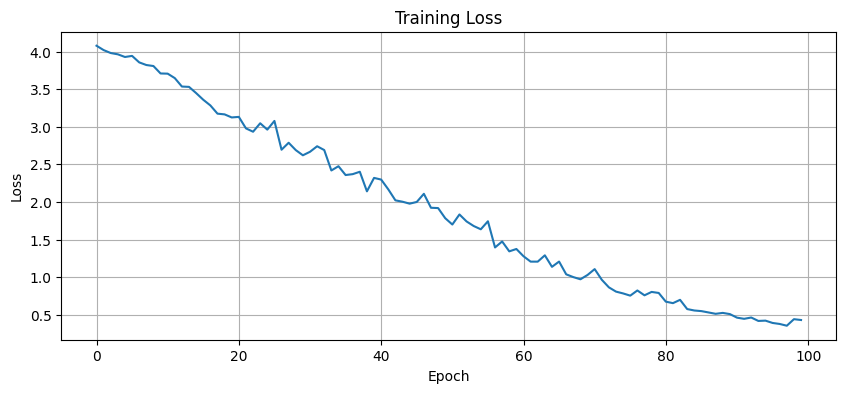


Final loss: 0.4290


In [8]:
# Hyperparameters
EMB_DIM = 64
HIDDEN_DIM = 128
EPOCHS = 100
LR = 1e-3
BATCH_SIZE = len(train_src_ids)  # Use full batch for small dataset

print(f"=== Training Configuration ===")
print(f"Embedding dim: {EMB_DIM}")
print(f"Hidden dim: {HIDDEN_DIM}")
print(f"Epochs: {EPOCHS}")
print(f"Learning rate: {LR}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Device: {DEVICE}")

# Create model
encoder = Encoder(
    vocab_size=len(src_vocab),
    emb_dim=EMB_DIM,
    hidden_dim=HIDDEN_DIM,
    pad_id=src_vocab.word2id["<PAD>"]
).to(DEVICE)

decoder = Decoder(
    vocab_size=len(tgt_vocab),
    emb_dim=EMB_DIM,
    hidden_dim=HIDDEN_DIM,
    pad_id=tgt_vocab.word2id["<PAD>"]
).to(DEVICE)

model = Seq2Seq(
    encoder=encoder,
    decoder=decoder,
    bos_id=tgt_vocab.word2id["<BOS>"],
    eos_id=tgt_vocab.word2id["<EOS>"]
).to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

# Define optimizer and loss
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss(ignore_index=tgt_vocab.word2id["<PAD>"])

# Prepare training data
train_src_tensor = pad_sequences(train_src_ids, src_vocab.word2id["<PAD>"]).to(DEVICE)
train_tgt_tensor = pad_sequences(train_tgt_ids, tgt_vocab.word2id["<PAD>"]).to(DEVICE)

print(f"\nTraining data shapes:")
print(f"  Source: {train_src_tensor.shape}")
print(f"  Target: {train_tgt_tensor.shape}")

# Training loop
print("\n=== Training ===")
model.train()
losses = []

for epoch in range(EPOCHS):
    optimizer.zero_grad()
    
    # Forward pass with teacher forcing
    outputs = model(train_src_tensor, train_tgt_tensor, teacher_forcing_ratio=0.5)
    
    # Compute loss (ignore <BOS> at position 0, predict from position 1)
    # outputs: [batch, tgt_len, vocab_size]
    # train_tgt_tensor: [batch, tgt_len]
    
    outputs_flat = outputs[:, 1:, :].reshape(-1, outputs.size(-1))  # [batch*(tgt_len-1), vocab]
    targets_flat = train_tgt_tensor[:, 1:].reshape(-1)  # [batch*(tgt_len-1)]
    
    loss = criterion(outputs_flat, targets_flat)
    
    # Backward pass
    loss.backward()
    
    # Gradient clipping (optional but recommended)
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    
    optimizer.step()
    
    losses.append(loss.item())
    
    # Print progress
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:3d}/{EPOCHS}] Loss: {loss.item():.4f}")

print("\n✓ Training complete!")

# Plot loss
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)
plt.show()

print(f"\nFinal loss: {losses[-1]:.4f}")

## 8. Evaluate on the dev set

In [9]:
# Prepare dev data
dev_src_tensor = pad_sequences(dev_src_ids, src_vocab.word2id["<PAD>"]).to(DEVICE)
dev_tgt_tensor = pad_sequences(dev_tgt_ids, tgt_vocab.word2id["<PAD>"]).to(DEVICE)

print("=== Evaluation on Dev Set ===")
print(f"Dev set size: {len(dev_src)}")

# Set model to eval mode
model.eval()

# Generate predictions with greedy decoding
predictions = model.greedy_decode(dev_src_tensor, max_len=20)

# Compute exact match accuracy
correct = 0
total = len(dev_src)

print("\n" + "="*80)
print("Source | Reference | Prediction | Match")
print("="*80)

for i in range(len(dev_src)):
    src_sent = dev_src[i]
    ref_sent = dev_tgt[i]
    
    # Decode prediction
    pred_ids = predictions[i]
    pred_sent = tgt_vocab.decode(pred_ids)
    
    # Check exact match (normalized)
    match = pred_sent.strip() == ref_sent.strip()
    if match:
        correct += 1
    
    # Print examples
    if i < 10:  # Print first 10 examples
        match_symbol = "✓" if match else "✗"
        print(f"{i+1:2d}. {src_sent}")
        print(f"    REF: {ref_sent}")
        print(f"    PRD: {pred_sent} {match_symbol}")
        print()

print("="*80)
accuracy = 100 * correct / total
print(f"\nExact Match Accuracy: {correct}/{total} = {accuracy:.2f}%")

# Additional metrics: count partially correct
print("\n=== Additional Analysis ===")
partial_correct = 0
for i in range(len(dev_src)):
    pred_sent = tgt_vocab.decode(predictions[i])
    ref_sent = dev_tgt[i]
    
    # Count as partial if any words match
    pred_words = set(pred_sent.split())
    ref_words = set(ref_sent.split())
    
    if len(pred_words & ref_words) > 0:
        partial_correct += 1

print(f"Partial Match (at least 1 word): {partial_correct}/{total} = {100*partial_correct/total:.2f}%")

# Evaluate on training set (to check overfitting)
print("\n=== Evaluation on Training Set (checking overfitting) ===")
train_predictions = model.greedy_decode(train_src_tensor, max_len=20)

train_correct = 0
for i in range(len(train_src)):
    pred_sent = tgt_vocab.decode(train_predictions[i])
    ref_sent = train_tgt[i]
    if pred_sent.strip() == ref_sent.strip():
        train_correct += 1

train_accuracy = 100 * train_correct / len(train_src)
print(f"Training Set Accuracy: {train_correct}/{len(train_src)} = {train_accuracy:.2f}%")

if train_accuracy > 90 and accuracy < 50:
    print("\n⚠️  Warning: Model is overfitting (high train acc, low dev acc)")
elif train_accuracy > 80:
    print("\n✓ Model is learning the training patterns well")
else:
    print("\n⚠️  Model may need more training or larger capacity")

=== Evaluation on Dev Set ===
Dev set size: 4

Source | Reference | Prediction | Match
 1. i am a teacher
    REF: tôi là giáo viên
    PRD: tôi là giáo viên ✓

 2. she likes music
    REF: cô ấy thích âm nhạc
    PRD: cô ấy thích âm nhạc ✓

 3. this is a book
    REF: đây là một cuốn sách
    PRD: đây là một cuốn sách ✓

 4. we study machine learning
    REF: chúng tôi học máy học
    PRD: chúng tôi yêu xử lý ngôn ngữ tự nhiên ✗


Exact Match Accuracy: 3/4 = 75.00%

=== Additional Analysis ===
Partial Match (at least 1 word): 4/4 = 100.00%

=== Evaluation on Training Set (checking overfitting) ===
Training Set Accuracy: 17/20 = 85.00%

✓ Model is learning the training patterns well


## 9. Conceptual Questions

### **Question 1: What is teacher forcing?**

**Answer:**

Teacher forcing là một kỹ thuật training cho sequence generation models. Thay vì sử dụng output dự đoán của model ở bước trước làm input cho bước tiếp theo, ta sử dụng **ground truth** (target thật) từ training data.

**Ví dụ:**
- Target sequence: `[<BOS>, tôi, là, sinh, viên, <EOS>]`
- **Với teacher forcing:** Decoder nhận input: `<BOS>` → dự đoán `tôi`, nhận `tôi` (ground truth) → dự đoán `là`, nhận `là` → ...
- **Không teacher forcing:** Decoder nhận input: `<BOS>` → dự đoán `tôi`, nhận `tôi` (dự đoán) → dự đoán `là`, nhận `là` (dự đoán) → ...

**Ưu điểm:**
- Training nhanh hơn và ổn định hơn
- Tránh error propagation trong quá trình training
- Giúp model hội tụ nhanh hơn

**Nhược điểm:**
- Exposure bias: model không thấy mistakes của chính nó trong training
- Có thể gây mismatch giữa training và inference

**Trong code:**
```python
use_teacher = random.random() < teacher_forcing_ratio
decoder_input = tgt[:, t] if use_teacher else predicted_token
```

---

### **Question 2: Why can a basic Seq2Seq model struggle with long sentences?**

**Answer:**

Basic Seq2Seq model gặp khó khăn với câu dài vì những lý do sau:

1. **Bottleneck problem:**
   - Toàn bộ thông tin của source sequence phải được nén vào một vector cố định (final hidden state)
   - Vector này có kích thước cố định (ví dụ: 128 dims), bất kể câu nguồn dài bao nhiêu
   - Với câu dài, thông tin quan trọng có thể bị mất hoặc bị "quên"

2. **Vanishing gradient:**
   - RNN/GRU xử lý sequence tuần tự
   - Với câu dài, gradient phải backprop qua nhiều timesteps
   - Information từ đầu câu có thể bị "diluted" khi đến cuối câu

3. **Sequential processing:**
   - Model phải "nhớ" toàn bộ câu nguồn trong một hidden state
   - Không có cơ chế để "nhìn lại" (look back) các phần khác nhau của source khi decode

**Giải pháp:**
- **Attention mechanism** (Lab 3): Cho phép decoder "attend" đến các phần khác nhau của source sequence ở mỗi bước decode
- **Transformer** (Lab 4): Loại bỏ sequential processing, xử lý parallel với self-attention

---

### **Question 3: What distribution does the decoder model at time step t?**

**Answer:**

Ở mỗi time step $t$, decoder mô hình hóa **conditional probability distribution**:

$$P(y_t \mid y_{<t}, x)$$

Trong đó:
- $y_t$: target token tại vị trí $t$
- $y_{<t} = (y_1, y_2, ..., y_{t-1})$: tất cả các token đã generate trước đó
- $x = (x_1, x_2, ..., x_T)$: source sequence

**Cụ thể:**
1. Decoder tính **logits** cho mỗi token trong vocabulary:
   ```python
   logits = self.fc(hidden)  # [batch, 1, vocab_size]
   ```

2. Logits được chuyển thành **probability distribution** qua softmax:
   $$P(y_t = w \mid y_{<t}, x) = \frac{\exp(\text{logit}_w)}{\sum_{w' \in V} \exp(\text{logit}_{w'})}$$

3. Training loss là **negative log-likelihood**:
   $$L = -\sum_{t=1}^{T'} \log P(y_t \mid y_{<t}, x)$$
   
   Equivalent với **cross-entropy loss**.

**Ví dụ:**
- Vocabulary: `{tôi: 0, là: 1, sinh: 2, viên: 3, ...}`
- Tại bước $t=2$, đã generate `[<BOS>, tôi]`
- Decoder output: `logits = [0.1, 4.5, 0.3, 0.2, ...]`
- Sau softmax: `P(y_2="là"|...) = 0.92, P(y_2="sinh"|...) = 0.03, ...`
- Model chọn token có xác suất cao nhất: `là`

---

### **Summary:**
- **Teacher forcing**: Sử dụng ground truth thay vì predicted output trong training
- **Long sentence problem**: Bottleneck ở fixed-size hidden vector, giải quyết bằng Attention
- **Decoder distribution**: $P(y_t \mid y_{<t}, x)$ - conditional probability qua softmax

## 🎉 Lab 2 Complete!

### ✅ What We've Accomplished:

1. **✓ Data Preparation**
   - Built vocabularies with special tokens (`<PAD>`, `<BOS>`, `<EOS>`, `<UNK>`)
   - Encoded parallel corpus (English-Vietnamese)
   - Implemented sequence padding for batching

2. **✓ Model Architecture**
   - **Encoder**: GRU-based, processes source sequence → context vector
   - **Decoder**: GRU-based, generates target sequence step-by-step
   - **Seq2Seq**: Complete encoder-decoder with teacher forcing

3. **✓ Training**
   - Cross-entropy loss with padding mask
   - Teacher forcing for stable training
   - Gradient clipping to prevent exploding gradients
   
4. **✓ Inference**
   - Greedy decoding: select most probable token at each step
   - Stop when `<EOS>` generated or max length reached

5. **✓ Evaluation**
   - Exact match accuracy on dev set
   - Comparison with training set to detect overfitting
   
---

### 🔑 Key Takeaways:

**Strengths of Seq2Seq:**
- ✅ Simple and elegant architecture
- ✅ Can handle variable-length input/output
- ✅ End-to-end differentiable

**Limitations:**
- ⚠️ **Bottleneck problem**: All source information compressed into single vector
- ⚠️ Struggles with long sentences
- ⚠️ No mechanism to focus on relevant source parts

**Next Steps:**
- **Lab 3**: Add **Attention Mechanism** to solve the bottleneck problem
- **Lab 4**: Implement **Transformer** with self-attention for better parallelization

---

### 📊 Expected Behavior:
For this small dataset:
- Training loss should decrease steadily
- Model should memorize common patterns
- High training accuracy, moderate dev accuracy (overfitting is expected)

---

### 🚀 Ready for Lab 3: Attention Mechanism!